## **Linear Regression Experimentation**
1. Required Library Imports

In [163]:
# Library Imports

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

2. Data Gathering

In [164]:
# Data Loading

data = fetch_california_housing()
X = data.data
y = data.target
print('Input Shape : ',X.shape,'\nOutput Shape : ',y.shape)

Input Shape :  (20640, 8) 
Output Shape :  (20640,)


3. Data Visualization and Preprocessing

In [165]:
df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


##### **California Housing Dataset – Feature Description**

The dataset predicts **Median House Value (in $100,000s)** using the following features:

- **MedInc** – Median income of households
- **HouseAge** – Median age of houses in the area
- **AveRooms** – Average number of rooms per household
- **AveBedrms** – Average number of bedrooms per household
- **Population** – Total population in the block
- **AveOccup** – Average number of people per household
- **Latitude** – Geographical latitude of the area
- **Longitude** – Geographical longitude of the area

### Target

- **MedHouseVal** – Median house value (in $100,000s)

#### Example
- `1.0` → $100,000  
- `2.5` → $250,000  
- `3.8` → $380,000  

> The model predicts house prices in units of $100,000.

In [166]:
df_train=df.sample(frac=0.8, random_state=42)
df_test=df.drop(df_train.index)

In [167]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 20046 to 11410
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      16512 non-null  float64
 1   HouseAge    16512 non-null  float64
 2   AveRooms    16512 non-null  float64
 3   AveBedrms   16512 non-null  float64
 4   Population  16512 non-null  float64
 5   AveOccup    16512 non-null  float64
 6   Latitude    16512 non-null  float64
 7   Longitude   16512 non-null  float64
 8   Target      16512 non-null  float64
dtypes: float64(9)
memory usage: 1.3 MB


##### Key Observations
- No **missing** values
- All columns are **numerical**

In [168]:
df_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.870452,28.657703,5.416425,1.094096,1421.894016,3.078749,35.625094,-119.565125,2.067734
std,1.896270,12.590337,2.281191,0.447393,1109.246995,10.934039,2.132973,2.000526,1.152397
min,0.499900,1.000000,0.846154,0.333333,5.000000,1.060606,32.540000,-124.350000,0.149990
25%,2.566625,18.000000,4.439360,1.005601,788.000000,2.431352,33.930000,-121.790000,1.194000
50%,3.534850,29.000000,5.226796,1.047862,1165.000000,2.816909,34.255000,-118.490000,1.798500
75%,4.743250,37.000000,6.047516,1.099493,1722.000000,3.286385,37.710000,-118.010000,2.652250
max,15.000100,52.000000,132.533333,34.066667,28566.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

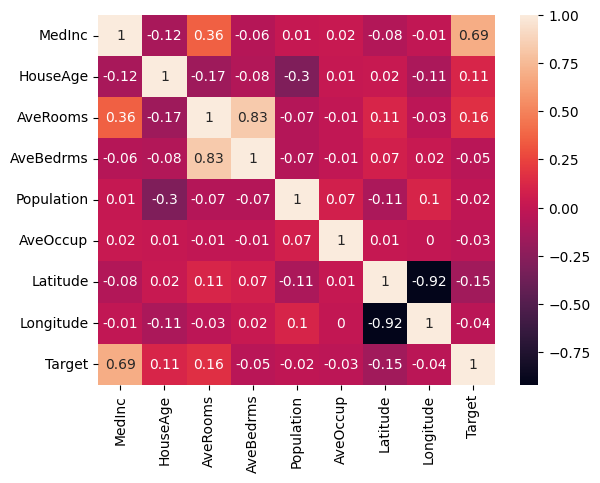

In [169]:
# visualize relationship in between columns using heartmap
sns.heatmap(round(df_train.corr(),2),annot=True)

#### **Key Observations**

- **MedInc (0.69)** has the strongest positive correlation with house prices → most important feature.
- **AveRooms (0.15)** and **HouseAge (0.11)** show weak positive correlation.
- **Population** and **AveOccup** have almost no linear impact.
- **Latitude (-0.14)** shows slight negative correlation with price.
- **AveRooms & AveBedrms (0.85)** are highly correlated → possible multicollinearity.
- **Latitude & Longitude (-0.92)** are strongly correlated with each other.

> Income is the dominant predictor, and some features show multicollinearity.

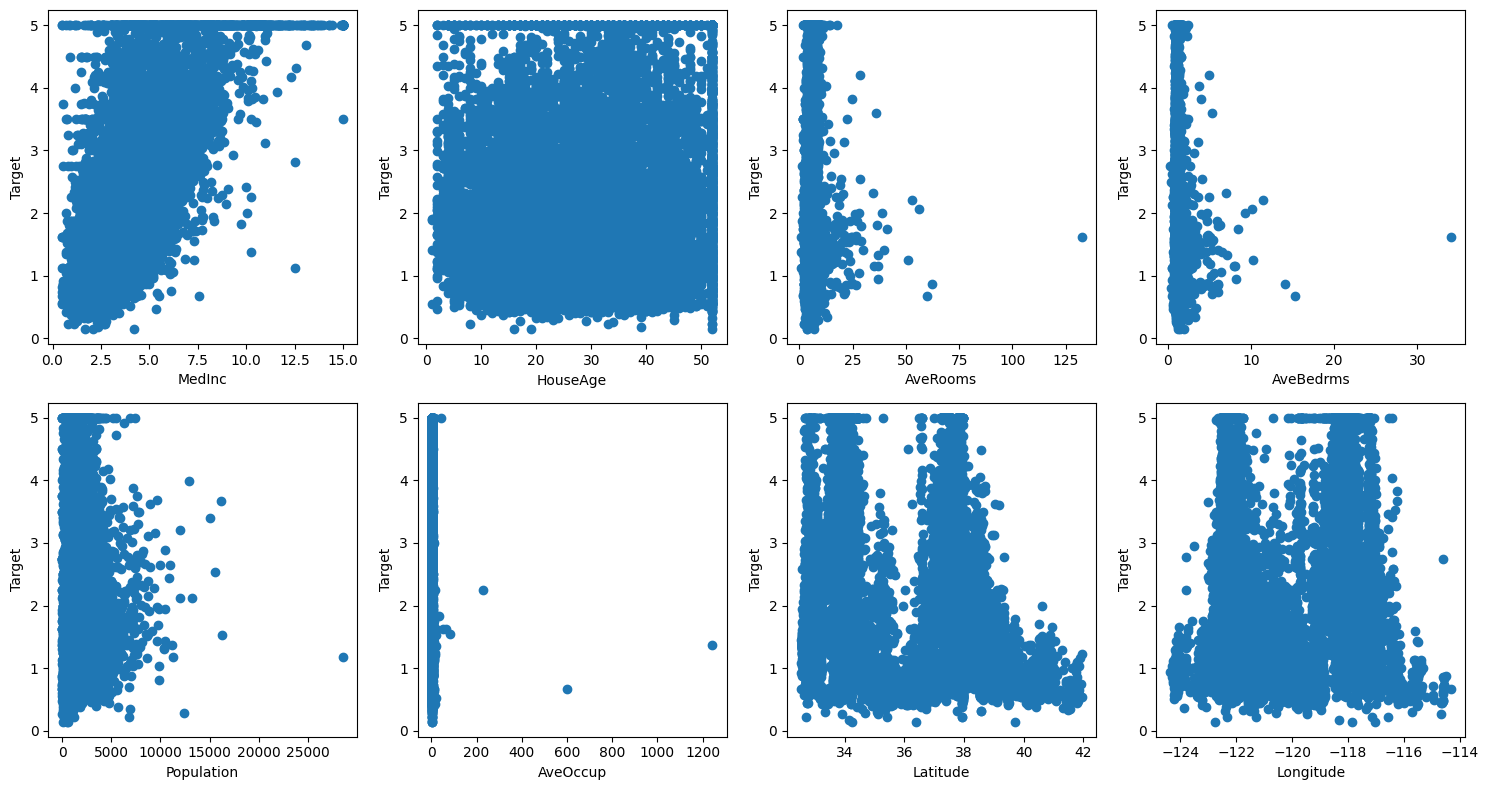

In [170]:
features = df_train.columns[:-1]
target = df_train['Target']

plt.figure(figsize=(15,8))

for index, feature in enumerate(features):
    plt.subplot(2, 4, index+1)
    plt.scatter(df_train[feature], target)
    plt.xlabel(feature)
    plt.ylabel("Target")

plt.tight_layout()
plt.show()

In [171]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_train[features], df_train['Target'], test_size=0.2, random_state=20)
print('Train Input Shape : ',X_train.shape,'\nTrain Output Shape : ',y_train.shape)
print('Test Input Shape : ',X_test.shape,'\nTest Output Shape : ',y_test.shape)

Train Input Shape :  (13209, 8) 
Train Output Shape :  (13209,)
Test Input Shape :  (3303, 8) 
Test Output Shape :  (3303,)


In [172]:
# Building Pipeline and ColumnTransformer for baseline model
col_transformer = ColumnTransformer(transformers=[
                    ('num', StandardScaler(), features)
                    ])
pipeline = Pipeline(steps=[
    ('preprocessor', col_transformer),
    ('model', LinearRegression())
    ])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [173]:
# Inference using pipeline
y_pred_pipeline = pipeline.predict(X_test)
# Evaluation
mse_pipeline = mean_absolute_error(y_test, y_pred_pipeline)
r2_pipeline = r2_score(y_test, y_pred_pipeline)
print("Mean Absolute Error : ", mse_pipeline)
print("R2 Score : ", r2_pipeline)

Mean Absolute Error :  0.5318275833105134
R2 Score :  0.5740795196940307


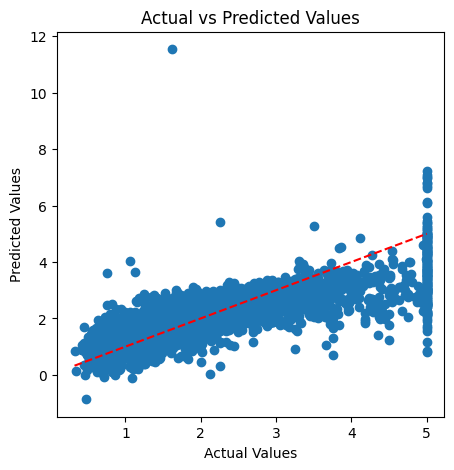

In [174]:
# Y_pred vs Y_test plot
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_pipeline)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line for perfect predictions
plt.show()

# Improvement Areas
- **Feature Engineering**: Create new features like `RoomsPerHousehold` to capture more complex relationships.
- **Outlier Detection**: Identify and handle outliers in all features which may skew the model.

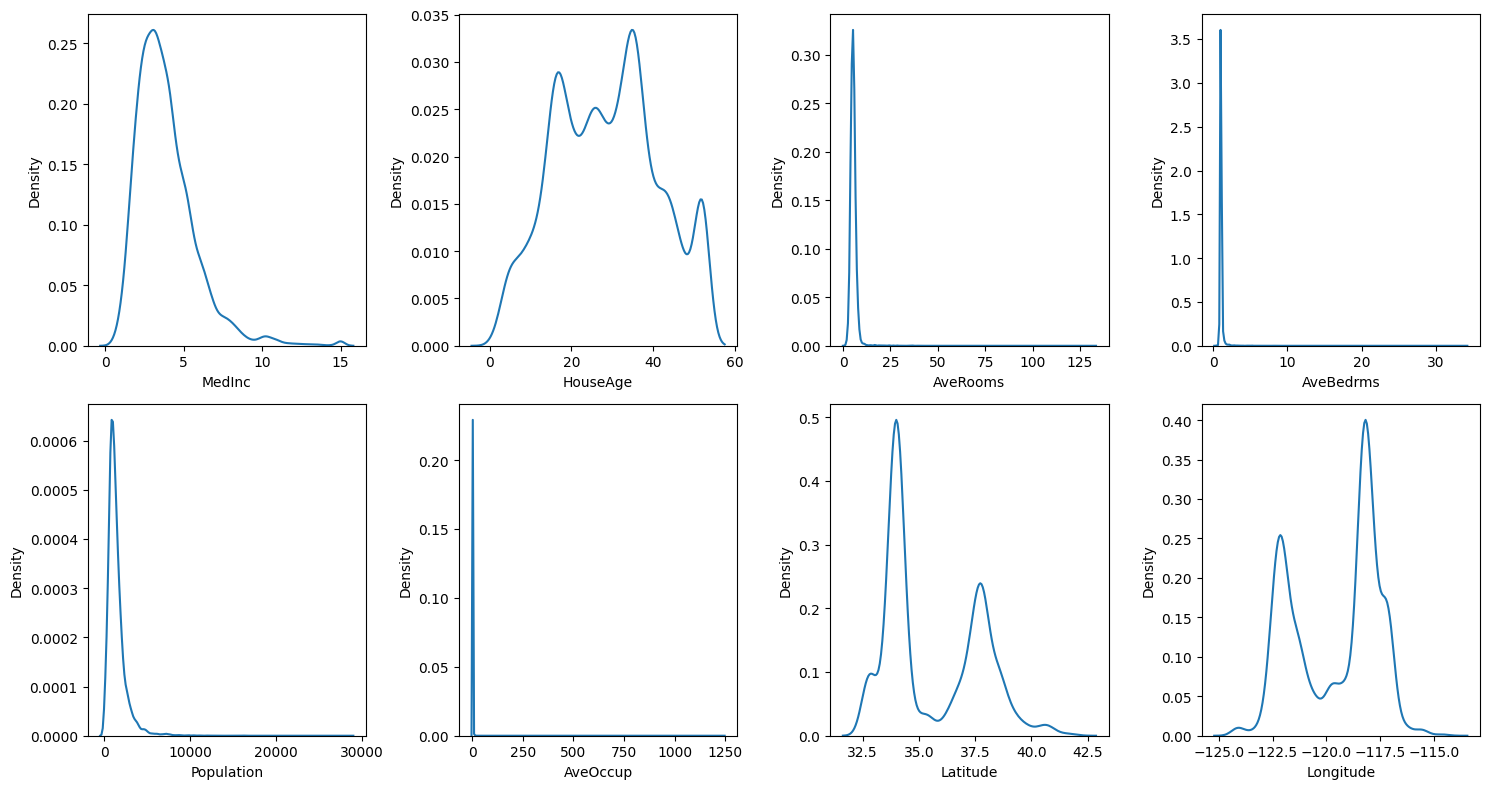

In [175]:
# Outlier Detection of all features using histplot
plt.figure(figsize=(15,8))
for index, feature in enumerate(features):
    plt.subplot(2, 4, index+1)
    sns.kdeplot(df_train[feature])
    plt.xlabel(feature)
plt.ylabel("Density")
plt.tight_layout()
plt.show()    

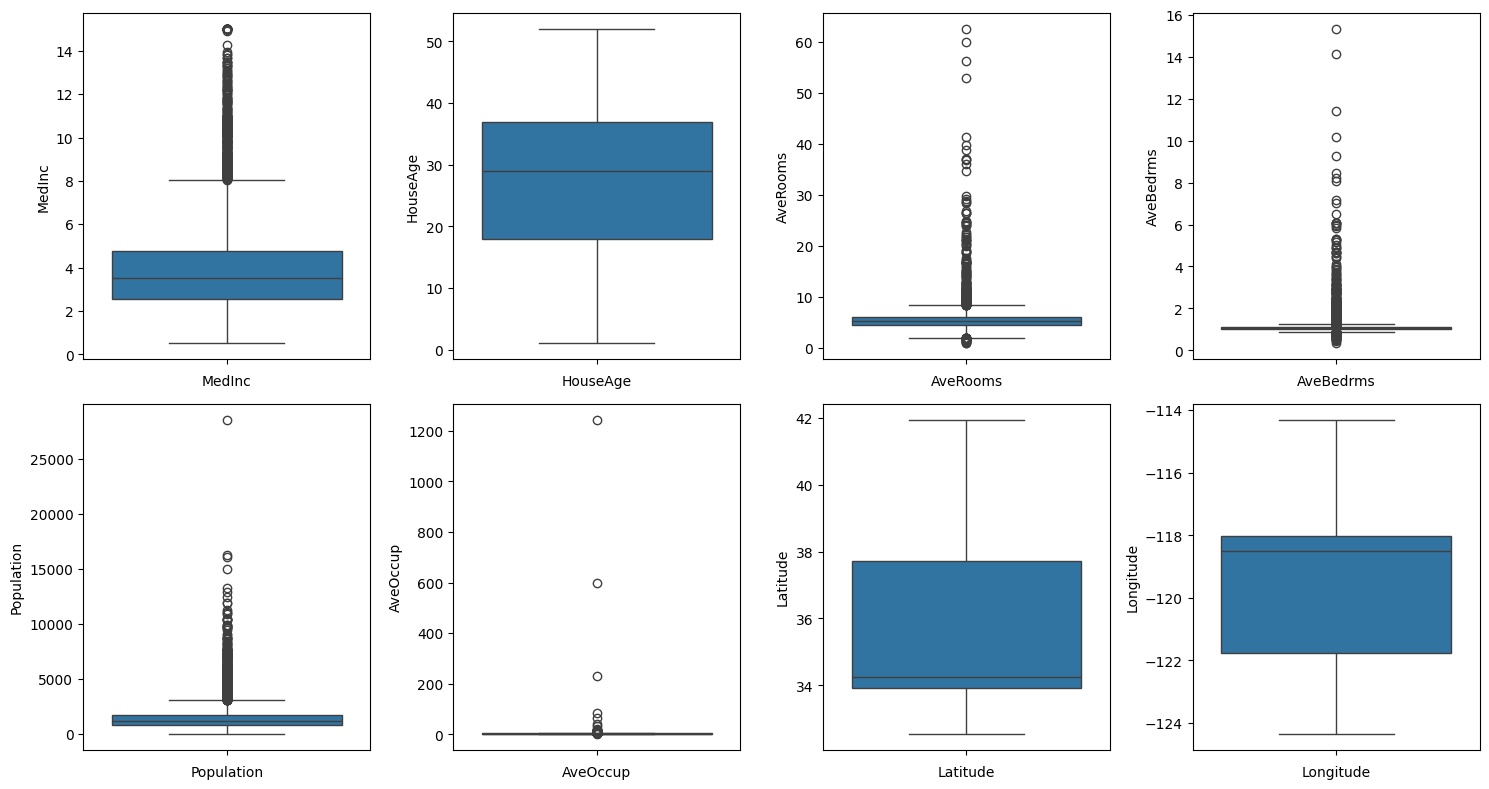

In [176]:
# Outlier Detection using boxplot on train data

plt.figure(figsize=(15,8))
for index, feature in enumerate(features): 
    plt.subplot(2, 4, index+1)
    sns.boxplot(X_train[feature])
    plt.xlabel(feature)
plt.tight_layout()
plt.show()

From boxplot, we can observe that there are outliers in `MedInc`, `AveRooms`,`AveBedrms`,`Population` and `AveOccup`. These outliers can skew the model's performance, so we may consider handling them through techniques like capping or transformation.

In [177]:
# Data transformation using log transformation on `MedInc`,`MedInc`, `AveRooms`,`AveBedrms`,`Population` and `AveOccup` feature
X_train_log = X_train.copy()
X_train_log.iloc[:, [0, 2, 3, 4, 5]] = np.log1p(X_train_log.iloc[:, [0, 2, 3, 4, 5]])

X_test_log = X_test.copy()
X_test_log.iloc[:, [0, 2, 3, 4, 5]] = np.log1p(X_test_log.iloc[:, [0, 2, 3, 4, 5]])

In [178]:
# LinearRegression with log transformed data
model_log = LinearRegression()
model_log.fit(X_train_log, y_train)
y_pred_log = model_log.predict(X_test_log)

In [179]:
# evaluation of log transformed data
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)
print("Mean Absolute Error (Log Transformed) : ", mae_log)
print("R2 Score (Log Transformed) : ", r2_log)

Mean Absolute Error (Log Transformed) :  0.5283514079906345
R2 Score (Log Transformed) :  0.6125464782395077


In [180]:
# Building Pipeline and ColumnTransformer for log transformed data

log_features = [0, 2, 3, 4, 5]

# Step 1: Log transform only selected columns
preprocessor_log = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p, validate=False), log_features)
    ],
    remainder='passthrough'   # keep other columns unchanged
)

# Step 2: Full pipeline
pipeline_log = Pipeline(steps=[
    ('log_transform', preprocessor_log),   # apply log only
    ('scaler', StandardScaler()),          # scale ALL columns
    ('model', LinearRegression())
])

pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('log_transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  [0, 2, 3, 4, 5])])),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [181]:
# Inference using pipeline
y_pred_pipeline = pipeline.predict(X_test)
# Evaluation
mse_pipeline = mean_absolute_error(y_test, y_pred_pipeline)
r2_pipeline = r2_score(y_test, y_pred_pipeline)
print("Mean Absolute Error : ", mse_pipeline)
print("R2 Score : ", r2_pipeline)

Mean Absolute Error :  0.5318275833105134
R2 Score :  0.5740795196940307


### **Feature Engineering**

In [182]:
df_train.corr()['Target'].sort_values(ascending=False)

Target        1.000000
MedInc        0.689752
AveRooms      0.157999
HouseAge      0.107050
Population   -0.024618
AveOccup     -0.027295
Longitude    -0.041830
AveBedrms    -0.054299
Latitude     -0.148438
Name: Target, dtype: float64

In [183]:
X_train, X_test, y_train, y_test = train_test_split(df_train.drop('Target', axis=1), df_train['Target'], test_size=0.2, random_state=20)
print('Train Input Shape : ',X_train.shape,'\nTrain Output Shape : ',y_train.shape)
print('Test Input Shape : ',X_test.shape,'\nTest Output Shape : ',y_test.shape)

Train Input Shape :  (13209, 8) 
Train Output Shape :  (13209,)
Test Input Shape :  (3303, 8) 
Test Output Shape :  (3303,)


In [184]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
18445,6.2957,25.0,6.627832,1.008091,2128.0,3.443366,37.25,-121.81
6999,3.2250,37.0,5.139842,1.042216,1163.0,3.068602,33.96,-118.04
7532,1.9957,32.0,3.650289,0.962428,1789.0,5.170520,33.92,-118.22
20459,5.3681,26.0,6.048421,1.010526,1915.0,4.031579,34.28,-118.77
10684,6.6178,44.0,6.839552,1.235075,515.0,1.921642,33.51,-117.78
...,...,...,...,...,...,...,...,...
19271,4.6792,23.0,6.382716,0.971193,555.0,2.283951,38.44,-122.82
16624,2.6205,27.0,5.371482,1.333959,930.0,1.744841,35.35,-120.84
2681,1.5372,23.0,3.760309,0.961340,1148.0,2.958763,32.99,-115.54
181,1.9375,52.0,4.209677,0.989247,488.0,2.623656,37.80,-122.23


In [185]:
def feature_engineering(df):

    df = df.copy()

    df['AveBedrms_per_AveRooms'] = df['AveBedrms'] / df['AveRooms']
    df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']

    return df.drop(['Population','AveOccup','Longitude','AveBedrms'], axis=1)

preprocessor = ColumnTransformer(
    transformers=[
        ('log_income', FunctionTransformer(np.log1p, validate=False), ['MedInc']),
        ('scale', StandardScaler(),
         ['HouseAge','AveRooms','AveBedrms_per_AveRooms','RoomsPerHousehold'])
    ],
    remainder='passthrough'
)

pipeline_fe = Pipeline([
    ('feature_engineering', FunctionTransformer(feature_engineering, validate=False)),
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_fe.fit(X_train, y_train)

c:\Users\kadam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1624: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x00000170E05E6200>)),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log_income',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['MedInc']),
                                                 ('scale', StandardScaler(),
                                                  ['HouseAge', 'AveRooms',
                                                   'AveBedrms_per_AveRooms',
                                                   'RoomsPerHousehold'])])),
                ('model', LinearRegression())])

In [186]:
# Inference using pipeline
y_pred_fe = pipeline_fe.predict(X_test)
# Evaluation
mae_fe = mean_absolute_error(y_test, y_pred_fe)
r2_fe = r2_score(y_test, y_pred_fe)
print("Mean Absolute Error (Feature Engineered) : ", mae_fe)
print("R2 Score (Feature Engineered) : ", r2_fe)

Mean Absolute Error (Feature Engineered) :  0.5578600315343692
R2 Score (Feature Engineered) :  0.5640326550529626


#### **Compare Model Performance**
| Model                 | Mean Absolute Error (MAE) | R2 Score |
|-----------------------|---------------------------|----------|
| Linear Regression     | 0.53                    | 0.57     |
| Linear Regression (Log Transformed) | 0.52                     | 0.61 |
| Linear Regression (Feature Engineered) | 0.55                    | 0.56 |
> Log transformation improved the model's performance by reducing MAE and increasing R2 Score, indicating better fit to the data.